In [1]:
print("Python töötab!")



Python töötab!


In [2]:
import pandas as pd
import plotly.express as px

print("Pandas töötab:", pd.__version__)

Pandas töötab: 3.0.5


In [3]:
from supabase import create_client

print("Supabase töötab!")

Supabase töötab!


In [5]:
SUPABASE_URL = "https://bf...supabase.co"
SUPABASE_KEY = "sb_publishable_..."
print("Ühendus loodud!")

Ühendus loodud!


In [6]:
from supabase import create_client

SUPABASE_URL = "https://bftwxvtmhgbrjjdardpy.supabase.co"
SUPABASE_KEY = "sb_publishable_ltcj7VjMgmv1Dl5YwQqsgA_r4it1IQ0"

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

print("Ühendus loodud!")

Ühendus loodud!


In [7]:
import pandas as pd

def get_data(table_name):
    data = []
    page_size = 1000
    page = 0

    while True:
        response = (
            supabase
            .table(table_name)
            .select("*")
            .range(
                page * page_size,
                (page + 1) * page_size - 1
            )
            .execute()
        )

        data.extend(response.data)

        if len(response.data) < page_size:
            break

        page += 1

    return pd.DataFrame(data)


df_sales = get_data("sales")
df_customers = get_data("customers")
df_products = get_data("products")

print("Sales:", df_sales.shape)
print("Customers:", df_customers.shape)
print("Products:", df_products.shape)

Sales: (15234, 12)
Customers: (3150, 9)
Products: (362, 9)


In [8]:
df = pd.merge(
    df_sales,
    df_customers,
    on="customer_id",
    how="left"
)

df = pd.merge(
    df,
    df_products,
    on="product_id",
    how="left"
)

print("Ühendatud tabeli mõõtmed:", df.shape)
print("\nEsimesed 5 rida:")
display(df.head())

print("\nVeergude nimed:")
print(df.columns.tolist())

Ühendatud tabeli mõõtmed: (15234, 28)

Esimesed 5 rida:


,id,sale_id,invoice_id,sale_date,customer_id,product_id,quantity,unit_price,total_price,channel,...,loyalty_tier,birth_year,product_name,category,subcategory,supplier,cost_price,retail_price,eco_certified,created_at
0,1,1,INV-202301-00001,2023-01-10T00:00:00,2588.0,1274,2,234.79,469.58,pood,...,bronze,1997.0,Soe teksane chino püksid,meeste_riided,püksid,Tartu Tekstiil AS,156.71,234.79,False,2024-09-13
1,2,2,INV-202301-00002,2023-01-16T00:00:00,4338.0,1207,2,241.13,482.26,pood,...,NaN,1996.0,Õhuline seemisnahkne rannasandaalid,jalanõusid,sandaalid,Türgi Tekstil A.Ş.,170.10,241.13,True,2021-10-18
2,3,3,INV-202301-00003,2023-01-05T00:00:00,4673.0,1264,1,258.46,221.19,pood,...,silver,1973.0,Mugav goretex platvormi kontsad,jalanõusid,kontsad,Itaalia Moda SRL,141.90,221.19,False,2024-11-21
3,4,4,INV-202301-00004,2023-01-02T00:00:00,4677.0,1341,3,45.21,135.63,pood,...,gold,1972.0,Stiilne siidine labakindad,aksessuaarid,kindad,Leedu Linane UAB,27.64,45.21,False,2020-07-06
4,5,5,INV-202301-00005,2023-01-13T00:00:00,2390.0,1284,1,99.57,99.57,pood,...,NaN,1996.0,Vintage softshell alussärk,laste_riided,trikotaaž,Vilma Design OÜ,59.84,99.57,True,2022-11-22



Veergude nimed:
['id', 'sale_id', 'invoice_id', 'sale_date', 'customer_id', 'product_id', 'quantity', 'unit_price', 'total_price', 'channel', 'store_location', 'payment_method', 'first_name', 'last_name', 'email', 'phone', 'city', 'registration_date', 'loyalty_tier', 'birth_year', 'product_name', 'category', 'subcategory', 'supplier', 'cost_price', 'retail_price', 'eco_certified', 'created_at']


In [9]:
print("=== ANDMETÜÜBID ===")
print(df.dtypes)

print("\n=== PUUDUVAD VÄÄRTUSED ===")
print(df.isnull().sum())

print("\n=== DUPLIKAATSED READ ===")
print("Duplikaate:", df.duplicated().sum())

print("\n=== NUMBRILISTE VEERGUDE KOKKUVÕTE ===")
display(df.describe())

=== ANDMETÜÜBID ===
id                     int64
sale_id                int64
invoice_id               str
sale_date                str
customer_id          float64
product_id             int64
quantity               int64
unit_price           float64
total_price          float64
channel                  str
store_location           str
payment_method           str
first_name               str
last_name                str
email                    str
phone                    str
city                     str
registration_date        str
loyalty_tier             str
birth_year           float64
product_name             str
category                 str
subcategory              str
supplier                 str
cost_price           float64
retail_price         float64
eco_certified         object
created_at               str
dtype: object

=== PUUDUVAD VÄÄRTUSED ===
id                      0
sale_id                 0
invoice_id              0
sale_date               0
customer_id          1

,id,sale_id,customer_id,product_id,quantity,unit_price,total_price,birth_year,cost_price,retail_price
count,15234.000000,15234.000000,13747.000000,15234.000000,15234.000000,15234.000000,15234.000000,13747.000000,15234.000000,15234.000000
mean,7617.500000,5036.686622,3502.959700,1175.239267,1.815544,164.231656,287.136095,1983.293664,107.786919,162.425100
std,4397.821336,2920.881848,844.237537,101.432698,1.037208,93.792130,273.681282,13.536817,63.039324,92.664009
min,1.000000,1.000000,2001.000000,1001.000000,1.000000,12.830000,-1405.320000,1960.000000,10.150000,13.530000
25%,3809.250000,2502.250000,2792.500000,1086.000000,1.000000,86.460000,116.980000,1971.000000,57.940000,86.140000
50%,7617.500000,5003.500000,3556.000000,1177.000000,1.000000,149.550000,219.190000,1984.000000,98.370000,149.470000
75%,11425.750000,7557.750000,4206.000000,1262.000000,2.000000,229.550000,374.540000,1995.000000,149.360000,225.810000
max,15234.000000,10118.000000,5000.000000,1350.000000,5.000000,512.370000,2170.400000,2005.000000,346.700000,434.080000


In [10]:
rfm_data = df[
    ["customer_id", "sale_date", "total_price"]
].copy()

rfm_data["sale_date"] = pd.to_datetime(
    rfm_data["sale_date"],
    errors="coerce"
)

rfm_data = rfm_data.dropna(
    subset=["customer_id", "sale_date", "total_price"]
)

rfm_data = rfm_data[
    rfm_data["total_price"] > 0
]

rfm_data["customer_id"] = rfm_data["customer_id"].astype(int)

print("RFM andmete mõõtmed:", rfm_data.shape)
print("\nPuuduvad väärtused:")
print(rfm_data.isnull().sum())

print("\nVäikseim ja suurim tehing:")
print(rfm_data["total_price"].min())
print(rfm_data["total_price"].max())

display(rfm_data.head())

RFM andmete mõõtmed: (13468, 3)

Puuduvad väärtused:
customer_id    0
sale_date      0
total_price    0
dtype: int64

Väikseim ja suurim tehing:
15.09
2170.4


,customer_id,sale_date,total_price
0,2588,2023-01-10,469.58
1,4338,2023-01-16,482.26
2,4673,2023-01-05,221.19
3,4677,2023-01-02,135.63
4,2390,2023-01-13,99.57


In [11]:
analysis_date = rfm_data["sale_date"].max() + pd.Timedelta(days=1)

rfm = (
    rfm_data
    .groupby("customer_id")
    .agg(
        Recency=("sale_date", lambda x: (analysis_date - x.max()).days),
        Frequency=("sale_date", "count"),
        Monetary=("total_price", "sum")
    )
    .reset_index()
)

print("Analüüsi kuupäev:", analysis_date.date())
print("Klientide arv:", rfm.shape[0])

display(rfm.head())

Analüüsi kuupäev: 2026-06-29
Klientide arv: 2550


,customer_id,Recency,Frequency,Monetary
0,2001,577,4,463.96
1,2004,557,3,1830.64
2,2005,634,7,1739.06
3,2006,963,1,327.06
4,2007,515,1,318.63


In [12]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

def assign_segment(score):
    if score >= 13:
        return "VIP Champions"
    elif score >= 10:
        return "Loyal Customers"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm["RFM_Score"].apply(assign_segment)

print("Segmentide jaotus:")
print(rfm["Segment"].value_counts())

display(rfm.head())

Segmentide jaotus:
Segment
Potential Loyalists    768
Loyal Customers        667
At Risk                538
VIP Champions          465
Lost                   112
Name: count, dtype: int64


,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,2001,577,4,463.96,4,2,1,7,Potential Loyalists
1,2004,557,3,1830.64,4,2,4,10,Loyal Customers
2,2005,634,7,1739.06,3,4,4,11,Loyal Customers
3,2006,963,1,327.06,1,1,1,3,Lost
4,2007,515,1,318.63,5,1,1,7,Potential Loyalists


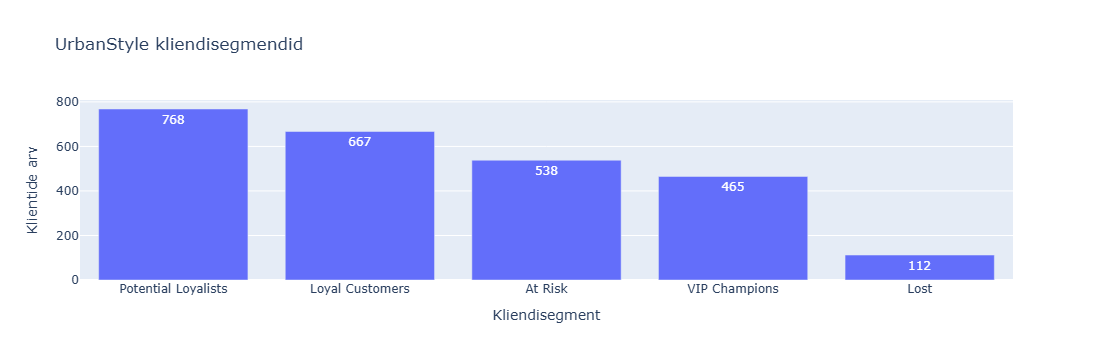

In [13]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Klientide arv"]

fig = px.bar(
    segment_counts,
    x="Segment",
    y="Klientide arv",
    title="UrbanStyle kliendisegmendid",
    text="Klientide arv"
)

fig.update_layout(
    xaxis_title="Kliendisegment",
    yaxis_title="Klientide arv",
    showlegend=False
)

fig.show()

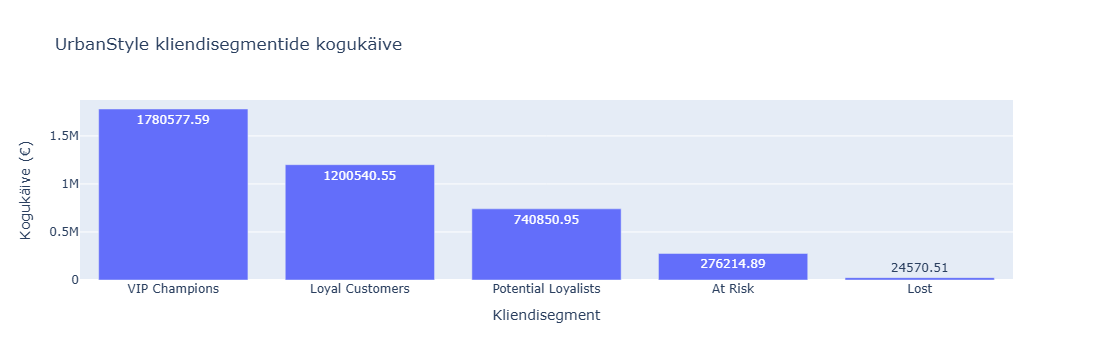

In [14]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .reset_index()
    .sort_values("Monetary", ascending=False)
)

fig = px.bar(
    segment_revenue,
    x="Segment",
    y="Monetary",
    title="UrbanStyle kliendisegmentide kogukäive",
    text_auto=".2f"
)

fig.update_layout(
    xaxis_title="Kliendisegment",
    yaxis_title="Kogukäive (€)",
    showlegend=False
)

fig.show()

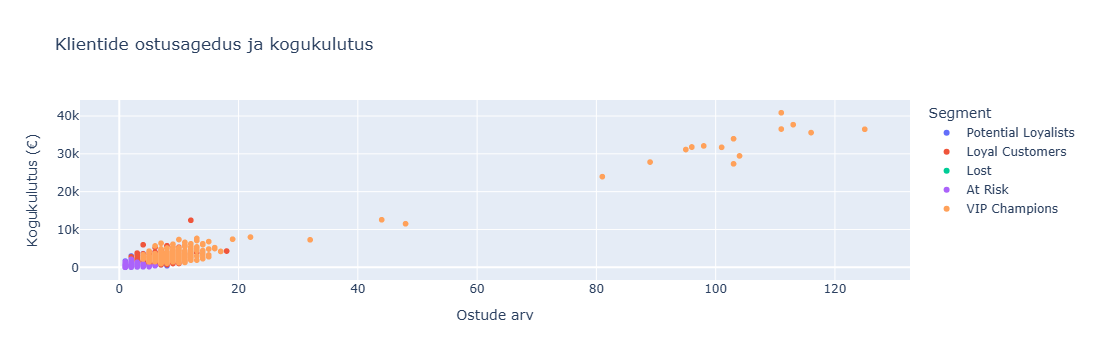

In [15]:
fig = px.scatter(
    rfm,
    x="Frequency",
    y="Monetary",
    color="Segment",
    hover_data=["customer_id", "Recency"],
    title="Klientide ostusagedus ja kogukulutus"
)

fig.update_layout(
    xaxis_title="Ostude arv",
    yaxis_title="Kogukulutus (€)"
)

fig.show()

In [16]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Klientide_arv=("customer_id", "count"),
        Keskmine_recency=("Recency", "mean"),
        Keskmine_ostude_arv=("Frequency", "mean"),
        Keskmine_kogukulu=("Monetary", "mean"),
        Kogukaive=("Monetary", "sum")
    )
    .round(2)
    .sort_values("Kogukaive", ascending=False)
)

display(segment_summary)

,Klientide_arv,Keskmine_recency,Keskmine_ostude_arv,Keskmine_kogukulu,Kogukaive
Segment,,,,,
VIP Champions,465,524.22,11.74,3829.20,1780577.59
Loyal Customers,667,634.84,5.90,1799.91,1200540.55
Potential Loyalists,768,682.68,3.63,964.65,740850.95
At Risk,538,798.95,2.13,513.41,276214.89
Lost,112,981.79,1.26,219.38,24570.51


In [17]:
## Peamised järeldused ja soovitused Markole

RFM-analüüsi põhjal jagunes 2550 klienti viide segmenti.

Kõige väärtuslikum segment on **VIP Champions**. Segmenti kuulub 465 klienti, kes tegid keskmiselt 11,74 ostu ning kulutasid keskmiselt 3829,20 eurot kliendi kohta. Segmendi kogukäive oli 1 780 577,59 eurot. Neile klientidele tuleks pakkuda VIP-programmi, personaalseid pakkumisi ja varajast ligipääsu uutele toodetele.

**Loyal Customers** segmenti kuulub 667 klienti ning nende kogukäive oli 1 200 540,55 eurot. Selle segmendi lojaalsust tuleks tugevdada punktisüsteemi, personaalsete soodustuste ja kordusostu kampaaniatega.

**Potential Loyalists** on suurim segment 768 kliendiga. Need kliendid on hea kasvupotentsiaaliga ning neid tuleks motiveerida järgmisele ostule tasuta tarne, sooduskoodi või seotud toodete pakkumisega.

**At Risk** segmenti kuulub 538 klienti. Nende viimasest ostust on möödunud keskmiselt 798,95 päeva. Sellele grupile tuleks kiiresti saata tagasivõitmise kampaania, näiteks „Me igatseme sind” pakkumine.

**Lost** segmenti kuulub 112 klienti. Nende ostusagedus ja kogukulu on väga väikesed, mistõttu tuleks enne suurema turunduskulu tegemist hinnata, kas nende tagasivõitmine on majanduslikult põhjendatud.

### Soovitus

UrbanStyle peaks esmajärjekorras hoidma VIP Champions ja Loyal Customers kliente ning samal ajal suunama Potential Loyalists segmendi kordusostule. Kõige kiiremat tähelepanu vajab At Risk segment, sest seal on 538 klienti, kelle varasem ostukäitumine näitab veel võimalikku tagasivõitmise potentsiaali.

SyntaxError: invalid character '„' (U+201E) (2476083374.py, line 11)

## Peamised järeldused ja soovitused Markole

RFM-analüüsi põhjal jagunes 2550 klienti viide segmenti.

Kõige väärtuslikum segment on **VIP Champions**. Segmenti kuulub 465 klienti, kes tegid keskmiselt 11,74 ostu ning kulutasid keskmiselt 3829,20 eurot kliendi kohta. Segmendi kogukäive oli 1 780 577,59 eurot. Neile klientidele tuleks pakkuda VIP-programmi, personaalseid pakkumisi ja varajast ligipääsu uutele toodetele.

**Loyal Customers** segmenti kuulub 667 klienti ning nende kogukäive oli 1 200 540,55 eurot. Selle segmendi lojaalsust tuleks tugevdada punktisüsteemi, personaalsete soodustuste ja kordusostu kampaaniatega.

**Potential Loyalists** on suurim segment 768 kliendiga. Need kliendid on hea kasvupotentsiaaliga ning neid tuleks motiveerida järgmisele ostule tasuta tarne, sooduskoodi või seotud toodete pakkumisega.

**At Risk** segmenti kuulub 538 klienti. Nende viimasest ostust on möödunud keskmiselt 798,95 päeva. Sellele grupile tuleks kiiresti saata tagasivõitmise kampaania, näiteks „Me igatseme sind” pakkumine.

**Lost** segmenti kuulub 112 klienti. Nende ostusagedus ja kogukulu on väga väikesed, mistõttu tuleks enne suurema turunduskulu tegemist hinnata, kas nende tagasivõitmine on majanduslikult põhjendatud.

### Soovitus

UrbanStyle peaks esmajärjekorras hoidma VIP Champions ja Loyal Customers kliente ning samal ajal suunama Potential Loyalists segmendi kordusostule. Kõige kiiremat tähelepanu vajab At Risk segment, sest seal on 538 klienti, kelle varasem ostukäitumine näitab veel võimalikku tagasivõitmise potentsiaali.